# MNIST — `xp` 재작성 + 백엔드 비교

`pure_mnist.py` 를 axon 의 `xp` 프록시로 갈아끼운 버전. autograd 는 아직 안 쓰고, 수동 backward 그대로.

- `np.foo(...)` → `xp.foo(...)` 로 교체
- 텐서 타입은 `axon.backend.Array[D]` Protocol — `D` 는 axon `DType` phantom
- 데이터 prep 은 numpy 로, 학습 루프 안에서 batch 마다 `xp.from_numpy` 변환
- **NumPy / MLX 두 백엔드를 한 번에 학습하고 결과를 나란히 비교**

In [1]:
import time
from abc import ABC, abstractmethod
from collections.abc import Iterator

import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import fetch_openml
from tqdm.notebook import tqdm

import axon
from axon import DType, xp
from axon.backend import Array, BackendName

## Optimizer

In [2]:
class Optimizer(ABC):
  def __init__(self, *, lr: float = 0.01):
    self._lr = lr

  @property
  def lr(self) -> float:
    return self._lr

  @lr.setter
  def lr(self, value: float):
    assert value > 0, "lr은 0보다 커야 합니다."
    self._lr = value

  @abstractmethod
  def step(self, X: Array, dX: Array): ...


class SGD(Optimizer):
  def step(self, X: Array, dX: Array):
    X -= dX * self.lr


class Adam(Optimizer):
  def __init__(self, *, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
    super().__init__(lr=lr)
    self.beta1 = beta1
    self.beta2 = beta2
    self.eps = eps
    self.t = 0
    self.m: dict[int, Array] = {}
    self.v: dict[int, Array] = {}

  def step(self, X: Array, dX: Array):
    param_id = id(X)
    if param_id not in self.m:
      self.m[param_id] = xp.zeros_like(X)
      self.v[param_id] = xp.zeros_like(X)

    self.t += 1
    self.m[param_id] = self.beta1 * self.m[param_id] + (1 - self.beta1) * dX
    self.v[param_id] = self.beta2 * self.v[param_id] + (1 - self.beta2) * dX**2

    m_hat = self.m[param_id] / (1 - self.beta1**self.t)
    v_hat = self.v[param_id] / (1 - self.beta2**self.t)

    X -= self.lr * m_hat / (xp.sqrt(v_hat) + self.eps)

## Module / Layer

In [3]:
class Module(ABC):
  @abstractmethod
  def forward(self, X: Array) -> Array: ...

  @abstractmethod
  def backward(self, delta: Array) -> Array: ...

  @abstractmethod
  def optimize(self, optimizer: Optimizer): ...

  @abstractmethod
  def format(self, indent: int = 0) -> str: ...

  def __str__(self):
    return self.format()

  def __repr__(self):
    return self.format()


class Linear(Module):
  W: Array[DType.FLOAT32]
  b: Array[DType.FLOAT32]
  dW: Array[DType.FLOAT32] | None
  db: Array[DType.FLOAT32] | None

  def __init__(self, in_features: int, out_features: int):
    self.in_features = in_features
    self.out_features = out_features
    self._cache_X: Array | None = None
    self.W = xp.random.normal((out_features, in_features), std=0.05, dtype=DType.FLOAT32)
    self.b = xp.zeros((out_features,), dtype=DType.FLOAT32)
    self.dW = None
    self.db = None

  def forward(self, X: Array) -> Array:
    self._cache_X = X
    return X @ xp.transpose(self.W) + self.b

  def backward(self, delta: Array) -> Array:
    X = self._cache_X
    assert X is not None, "forward 이전에 backward 호출 불가."
    self.db = xp.sum(delta, axis=0)
    self.dW = xp.transpose(delta) @ X
    return delta @ self.W

  def optimize(self, optimizer: Optimizer):
    assert self.dW is not None and self.db is not None
    optimizer.step(self.W, self.dW)
    optimizer.step(self.b, self.db)

  def format(self, indent: int = 0) -> str:
    return f"{'  ' * indent}Linear(in={self.in_features}, out={self.out_features})"


class Sigmoid(Module):
  def __init__(self):
    self._cache_Y: Array | None = None

  def forward(self, X: Array) -> Array:
    Y = 1.0 / (1.0 + xp.exp(-X))
    self._cache_Y = Y  # backward 효율화: σ' = σ(1-σ)
    return Y

  def backward(self, delta: Array) -> Array:
    Y = self._cache_Y
    assert Y is not None
    return delta * Y * (1.0 - Y)

  def optimize(self, optimizer: Optimizer):
    pass

  def format(self, indent: int = 0) -> str:
    return f"{'  ' * indent}Sigmoid()"


class ReLU(Module):
  def __init__(self):
    self._cache_X: Array | None = None

  def forward(self, X: Array) -> Array:
    self._cache_X = X
    return xp.maximum(xp.zeros_like(X), X)

  def backward(self, delta: Array) -> Array:
    X = self._cache_X
    assert X is not None
    return delta * (X > 0)

  def optimize(self, optimizer: Optimizer):
    pass

  def format(self, indent: int = 0) -> str:
    return f"{'  ' * indent}ReLU()"


class Sequential(Module):
  def __init__(self, modules: list[Module]):
    assert len(modules) > 0
    self.modules = modules

  def forward(self, X: Array) -> Array:
    x = X
    for module in self.modules:
      x = module.forward(x)
    return x

  def backward(self, delta: Array) -> Array:
    dX = delta
    for module in reversed(self.modules):
      dX = module.backward(dX)
    return dX

  def optimize(self, optimizer: Optimizer):
    for module in self.modules:
      module.optimize(optimizer)

  def format(self, indent: int = 0) -> str:
    indent_str = "  " * indent
    lines = [f"{indent_str}Sequential("]
    for module in self.modules:
      lines.append(f"{module.format(indent + 1)},")
    lines.append(f"{indent_str})")
    return "\n".join(lines)

## Loss

In [ ]:
class Loss(ABC):
  @abstractmethod
  def forward(self, Y: Array, T: Array) -> Array: ...

  @abstractmethod
  def backward(self) -> Array: ...


class CrossEntropyLoss(Loss):
  def __init__(self):
    self._cache_probs: Array | None = None
    self._cache_T: Array | None = None
    self._cache_N: int | None = None

  def forward(self, Y: Array, T: Array) -> Array:
    """Y: (N, C) logits, T: (N,) int 정답 인덱스. 반환은 0-d Array (Python float 아님 — on-device 누적용)."""
    N = int(Y.shape[0])

    # log-softmax 안정화
    max_by_row = xp.max(Y, axis=1, keepdims=True)
    shifted = Y - max_by_row
    exp_shifted = xp.exp(shifted)
    sum_by_row = xp.sum(exp_shifted, axis=1, keepdims=True)
    probs = exp_shifted / sum_by_row

    # 정답 클래스 확률 픽업 — 2D fancy indexing
    n = xp.arange(N, dtype=DType.INT32)
    log_probs = xp.log(probs[n, T] + 1e-9)

    self._cache_probs = probs
    self._cache_T = T
    self._cache_N = N

    return -xp.mean(log_probs)

  def backward(self) -> Array:
    probs = self._cache_probs
    T = self._cache_T
    N = self._cache_N
    assert probs is not None and T is not None and N is not None

    # dY = (probs - one_hot(T)) / N
    dY = xp.array(probs)  # copy
    n = xp.arange(N, dtype=DType.INT32)
    dY[n, T] -= 1.0
    dY /= N
    return dY

## 데이터 로드

In [5]:
mnist = fetch_openml("mnist_784", version=1, as_frame=False, parser="liac-arff")
X_all = mnist.data.astype(np.float32) / 255.0
T_all = mnist.target.astype(np.int32)

X_train_np, X_test_np = X_all[:60000], X_all[60000:]
T_train_np, T_test_np = T_all[:60000], T_all[60000:]

print("train:", X_train_np.shape, "test:", X_test_np.shape)

train: (60000, 784) test: (10000, 784)


## 학습 루프

데이터 prep 은 numpy 로 (셔플 등 — `xp` 에 `random.permutation` 없음), 배치 단위로 `xp.from_numpy` 변환.

In [ ]:
def iterate_minibatches(
  X_np: np.ndarray, T_np: np.ndarray, batch_size: int, *, shuffle: bool = False
) -> Iterator[tuple[Array, Array]]:
  N = X_np.shape[0]
  indices = np.random.permutation(N) if shuffle else np.arange(N)
  for start in range(0, N, batch_size):
    batch_idx = indices[start : start + batch_size]
    yield xp.from_numpy(X_np[batch_idx]), xp.from_numpy(T_np[batch_idx])


def run_epoch(
  module: Module,
  loss_fn: Loss,
  X_np: np.ndarray,
  T_np: np.ndarray,
  *,
  batch_size: int,
  training: bool,
  optimizer: Optimizer | None = None,
) -> dict[str, float]:
  """on-device 누적 — loss/correct 를 tensor 로 모으다가 epoch 끝에 한 번만 변환.

  매 배치 to_numpy 호출은 MLX lazy graph 를 강제 eval 시켜 GPU↔CPU sync 를 일으킨다.
  여기선 sync 를 epoch 단위로 줄여 MLX 가 graph 를 길게 흘릴 수 있게 한다.
  """
  N = X_np.shape[0]
  total_loss = xp.zeros((), dtype=DType.FLOAT32)
  total_correct = xp.zeros((), dtype=DType.INT64)
  total_seen = 0

  total_steps = (N + batch_size - 1) // batch_size
  batches = iterate_minibatches(X_np, T_np, batch_size, shuffle=training)

  for x, t in tqdm(batches, total=total_steps, leave=False):
    n = int(x.shape[0])
    y = module.forward(x)
    loss = loss_fn.forward(y, t)  # tensor scalar

    if training:
      assert optimizer is not None
      dy = loss_fn.backward()
      module.backward(dy)
      module.optimize(optimizer)
      # MLX: step 끝마다 eval 한 번 — graph 가 무한히 커지는 것 방지.
      # NumPy 백엔드는 no-op 이라 cost 없음.

    pred = xp.argmax(y, axis=1)
    correct_batch = xp.sum((pred == t))
    total_correct += correct_batch
    total_loss += loss * n
    total_seen += n

  # epoch 끝에 한 번만 sync.
  return {
    "loss": float(total_loss) / total_seen,
    "accuracy": float(total_correct) / total_seen,
  }


def train(
  module: Module,
  optimizer: Optimizer,
  loss_fn: Loss,
  X_train_np: np.ndarray,
  T_train_np: np.ndarray,
  X_test_np: np.ndarray,
  T_test_np: np.ndarray,
  *,
  epochs: int = 10,
  batch_size: int = 64,
  test_batch_size: int = 256,
  log_prefix: str = "",
) -> dict[str, list[float]]:
  history: dict[str, list[float]] = {
    "train_loss": [], "train_acc": [],
    "test_loss": [], "test_acc": [],
  }
  for epoch in range(1, epochs + 1):
    train_metrics = run_epoch(
      module, loss_fn, X_train_np, T_train_np,
      batch_size=batch_size, training=True, optimizer=optimizer,
    )
    test_metrics = run_epoch(
      module, loss_fn, X_test_np, T_test_np,
      batch_size=test_batch_size, training=False,
    )
    history["train_loss"].append(train_metrics["loss"])
    history["train_acc"].append(train_metrics["accuracy"])
    history["test_loss"].append(test_metrics["loss"])
    history["test_acc"].append(test_metrics["accuracy"])
    print(
      f"{log_prefix}epoch {epoch}/{epochs} | "
      f"train_loss={train_metrics['loss']:.4f} | "
      f"train_acc={train_metrics['accuracy']:.4%} | "
      f"test_loss={test_metrics['loss']:.4f} | "
      f"test_acc={test_metrics['accuracy']:.4%}"
    )
  return history

## 두 백엔드 동시 학습

동일 시드 / 동일 모델 구조로 NumPy 와 MLX 양쪽에서 학습. 결과/속도/수렴을 나란히 비교.

In [7]:
EPOCHS = 10
BATCH_SIZE = 64
SEED = 0


def build_model() -> Sequential:
  """set_backend 후에 호출 — 가중치 초기화가 현재 백엔드에서 발생."""
  return Sequential(
    [
      Linear(784, 128),
      ReLU(),
      Linear(128, 64),
      ReLU(),
      Linear(64, 10),
    ]
  )


results: dict[BackendName, dict] = {}

for backend in ("numpy", "mlx"):
  axon.set_backend(backend)
  np.random.seed(SEED)            # 셔플/배치 순서 동일
  xp.random.seed(SEED)            # 가중치 초기화 동일 (백엔드 RNG 알고리즘은 다름)

  model = build_model()
  optimizer = Adam(lr=1e-3)
  loss_fn = CrossEntropyLoss()

  print(f"\n=== backend={backend} ===")
  print(model)
  t0 = time.time()
  history = train(
    model, optimizer, loss_fn,
    X_train_np, T_train_np, X_test_np, T_test_np,
    epochs=EPOCHS, batch_size=BATCH_SIZE, log_prefix=f"[{backend}] ",
  )
  elapsed = time.time() - t0
  results[backend] = {"history": history, "elapsed": elapsed}
  print(f"[{backend}] total time: {elapsed:.2f}s")


=== backend=numpy ===
Sequential(
  Linear(in=784, out=128),
  ReLU(),
  Linear(in=128, out=64),
  ReLU(),
  Linear(in=64, out=10),
)


  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

[numpy] epoch 1/10 | train_loss=0.2876 | train_acc=91.2483% | test_loss=0.1568 | test_acc=95.2300%


  0%|          | 0/938 [00:00<?, ?it/s]

...

  0%|          | 0/40 [00:00<?, ?it/s]

[mlx] epoch 9/10 | train_loss=0.0187 | train_acc=99.4000% | test_loss=0.0796 | test_acc=97.9100%


  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

[mlx] epoch 10/10 | train_loss=0.0173 | train_acc=99.4050% | test_loss=0.0887 | test_acc=97.5700%
[mlx] total time: 15.44s


## 결과 비교

In [8]:
# 요약 표
print(f"{'backend':<10} {'final train_acc':>16} {'final test_acc':>16} {'time':>10}")
for backend, res in results.items():
  h = res["history"]
  print(
    f"{backend:<10} "
    f"{h['train_acc'][-1]:>15.4%} "
    f"{h['test_acc'][-1]:>15.4%} "
    f"{res['elapsed']:>9.2f}s"
  )

backend     final train_acc   final test_acc       time
numpy             99.5250%        97.6600%      7.87s
mlx               99.4050%        97.5700%     15.44s


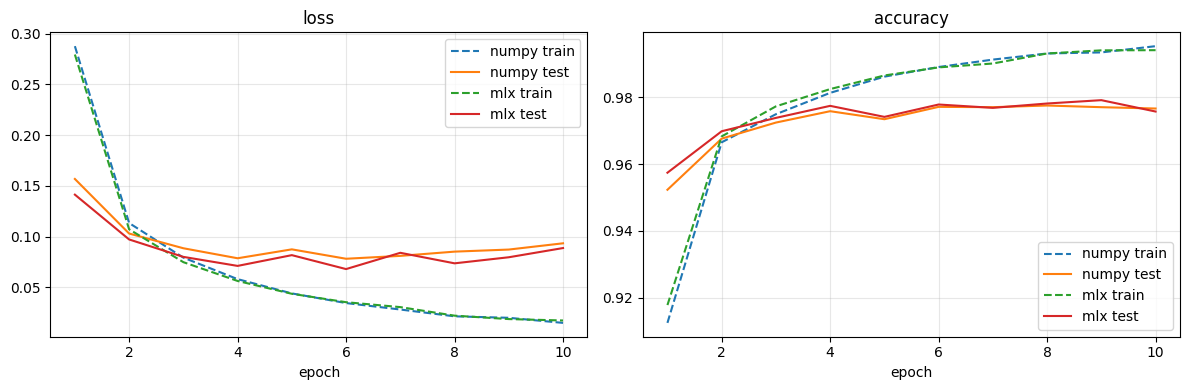

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_x = range(1, EPOCHS + 1)

for backend, res in results.items():
  h = res["history"]
  axes[0].plot(epochs_x, h["train_loss"], label=f"{backend} train", linestyle="--")
  axes[0].plot(epochs_x, h["test_loss"], label=f"{backend} test")
  axes[1].plot(epochs_x, h["train_acc"], label=f"{backend} train", linestyle="--")
  axes[1].plot(epochs_x, h["test_acc"], label=f"{backend} test")

axes[0].set_title("loss")
axes[0].set_xlabel("epoch")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].set_title("accuracy")
axes[1].set_xlabel("epoch")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()